# XAI

In [ ]:
import os

!apt-get update -qq
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

!pip install --upgrade pyspark==3.5.1 xgboost synapseml==1.0.8

from pyspark.sql import SparkSession

ss = (SparkSession.builder
    .master("local[*]")
    .appName("MARIDA-XAI")
    .config("spark.driver.memory", "4g")
    .config("spark.driver.maxResultSize", "1g")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.jars.packages", "com.microsoft.azure:synapseml_2.12:1.0.8")
    .config("spark.jars.repositories", "https://mmlspark.azureedge.net/maven")
    .getOrCreate()
)

try:
    jvm = ss._jvm
    _ = jvm.com.microsoft.azure.synapse.ml.explainers.TabularSHAP
    print("SynapseML JAR downloaded and loaded successfully into the JVM")
except Exception as e:
    print(f"Errore, JAR not found: {e}")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
SynapseML JAR downloaded and loaded successfully into the JVM


In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import *
from pyspark.sql.functions import *
import pandas as pd
from synapse.ml.core.platform import *
from xgboost.spark import SparkXGBClassifier
from google.colab import drive
from pyspark.ml import PipelineModel
from pyspark.sql.functions import rand
from pyspark.sql.types import ArrayType, FloatType

In [ ]:

drive.mount('/content/drive')

MODEL_PATH = "/content/drive/MyDrive/DDAM project/models/best_xgb_model_OVERSAMPLING"
path_test = "/content/drive/MyDrive/DDAM project/data/train_test/test_set.parquet"
path_train = "/content/drive/MyDrive/DDAM project/data/train_test/train_set.parquet"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
confidence_indexer = StringIndexer(inputCol="Confidence", outputCol="Confidence_idx", handleInvalid="keep")
confidence_ohe = OneHotEncoder(inputCol="Confidence_idx", outputCol="Confidence_ohe", dropLast=False)

prep_pipeline = Pipeline(stages=[confidence_indexer, confidence_ohe])


In [ ]:
df_train = ss.read.parquet(path_train)
df_test = ss.read.parquet(path_test)
loaded_model = PipelineModel.load(MODEL_PATH)

prep_model = prep_pipeline.fit(df_train)

df_test_transformed = prep_model.transform(df_test)

feature_cols = ["NDVI", "FDI", "NDWI", "NRD", "NDMI", "BSI", "CON", "DIS", "ENER", "COR", "PC_1", "Confidence_ohe"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

df_test_ready = assembler.transform(df_test_transformed)

# Explain
explain_instances = (
    loaded_model.transform(df_test_ready)
    .orderBy(rand())
    .limit(5)
    .repartition(200)
    .cache()
)

display(explain_instances)

DataFrame[Confidence: string, Class: string, NDVI: double, FDI: double, NDWI: double, NRD: double, NDMI: double, BSI: double, CON: double, DIS: double, ENER: double, COR: double, PC_1: double, Confidence_idx: double, Confidence_ohe: vector, features: vector, label: double, rawPrediction: vector, prediction: double, probability: vector]

In [ ]:
pip install shap

In [ ]:
import shap
import numpy as np
import pandas as pd
from pyspark.sql.functions import pandas_udf, col

xgb_stage = loaded_model.stages[-1]
booster = xgb_stage.get_booster()
broadcast_booster = ss.sparkContext.broadcast(booster)
TARGET_CLASS_ID = 8

@pandas_udf(ArrayType(FloatType()))
def calculate_shap_udf(features_series: pd.Series) -> pd.Series:
    bst = broadcast_booster.value

    # Converts the series to a 2D Numpy matrix
    X_matrix = np.stack(features_series.values)

    # Compute SHAP
    explainer = shap.TreeExplainer(bst)
    shap_vals = explainer.shap_values(X_matrix)

    if isinstance(shap_vals, list):

        target_shap = shap_vals[TARGET_CLASS_ID]
    else:
        target_shap = shap_vals[:, :, TARGET_CLASS_ID]

    return pd.Series([row.tolist() for row in target_shap])

df_with_array = df_test_ready.withColumn("features_array", vector_to_array(col("features")))

In [ ]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col

# Extract 8000 rows
df_sample_spark = df_with_array.orderBy(rand()).limit(8000).cache()
df_sample_spark.count()

df_shap_calcolato_spark = df_sample_spark.withColumn(
    "shap_values",
    calculate_shap_udf(col("features_array"))
)

# Final values
pdf_risultati = df_shap_calcolato_spark.select("features_array", "shap_values").toPandas()

# Reformat the data for the graph
X_matrix = np.stack(pdf_risultati["features_array"].values)
shap_vals = np.stack(pdf_risultati["shap_values"].values)

Feature importance:
 Feature  SHAP_Mean_Importance
     FDI              1.687097
    NDWI              1.473644
    NDMI              1.157610
     CON              1.114321
    High              0.987936
    PC_1              0.987907
     COR              0.887318
     NRD              0.524514
    NDVI              0.317126
     BSI              0.313137
    ENER              0.308781
     DIS              0.125168
Moderate              0.072416
     Low              0.055495
    Null              0.000000
--------------------------------------------------


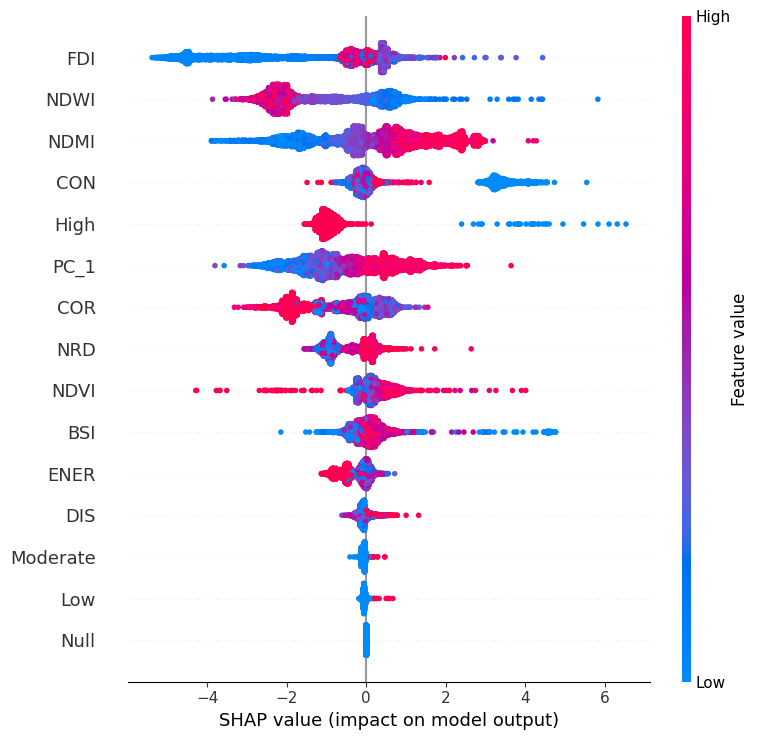

In [ ]:
feature_names = ["NDVI", "FDI", "NDWI", "NRD", "NDMI", "BSI", "CON", "DIS", "ENER", "COR", "PC_1", "High", "Moderate", "Low", "Null"]

mean_abs_shap = np.abs(shap_vals).mean(axis=0)

df_ranking = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Mean_Importance": mean_abs_shap
}).sort_values(by="SHAP_Mean_Importance", ascending=False)

print("Feature importance:")
print(df_ranking.to_string(index=False))
print("-" * 50)

num_features = X_matrix.shape[1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_matrix, feature_names=feature_names)

In the "pandas_udf" part, Spark takes the data from its Java environment, translates it for Python, calculates the SHAP of a single row, and then translates the result back into Java.
When you use @pandas_udf, you enable a technology called Apache Arrow. Arrow is a super-fast memory format that allows Java and Python to exchange huge blocks of data without having to constantly translate them.
Rather than calling your calculate_shap_udf function for every single row, Spark takes a "batch" of thousands of rows and passes them all to you at once as a pd.Series (a Pandas column).